In [1]:
import pandas as pd
import numpy as np

project_path = r"C:\Users\Bawan Singh\OneDrive\Documents\Arshleen\market-portfolio-risk-analysis"

In [2]:
performance_summary = pd.read_csv(
    project_path + r"\data\processed\performance_summary.csv",
    index_col=0
)

risk_summary = pd.read_csv(
    project_path + r"\data\processed\risk_summary.csv",
    index_col=0
)

In [3]:
performance_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha
Conservative,0.105047,0.108104,0.971717,0.369071,0.284624,0.039161
Balanced,0.123237,0.126049,0.977689,0.572608,0.215221,0.021016
Growth,0.187285,0.195982,0.955622,0.961729,0.194737,0.015599


In [4]:
risk_summary

,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility
Conservative,-0.010521,-0.015438,-0.250688,0.323070
Balanced,-0.011563,-0.018586,-0.248956,0.449790
Growth,-0.018348,-0.029343,-0.303071,0.707038


In [5]:
master_summary = performance_summary.join(risk_summary)

master_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility
Conservative,0.105047,0.108104,0.971717,0.369071,0.284624,0.039161,-0.010521,-0.015438,-0.250688,0.323070
Balanced,0.123237,0.126049,0.977689,0.572608,0.215221,0.021016,-0.011563,-0.018586,-0.248956,0.449790
Growth,0.187285,0.195982,0.955622,0.961729,0.194737,0.015599,-0.018348,-0.029343,-0.303071,0.707038


In [6]:
master_summary.to_csv(
    project_path + r"\data\processed\master_summary.csv"
)

In [7]:
master_summary_display = master_summary.copy()

master_summary_display

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility
Conservative,0.105047,0.108104,0.971717,0.369071,0.284624,0.039161,-0.010521,-0.015438,-0.250688,0.323070
Balanced,0.123237,0.126049,0.977689,0.572608,0.215221,0.021016,-0.011563,-0.018586,-0.248956,0.449790
Growth,0.187285,0.195982,0.955622,0.961729,0.194737,0.015599,-0.018348,-0.029343,-0.303071,0.707038


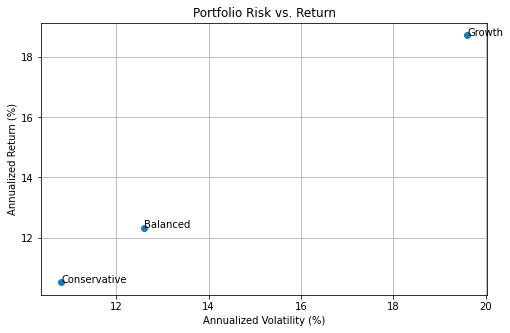

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    master_summary["Annualized Volatility"] * 100,
    master_summary["Annualized Return"] * 100
)

for portfolio in master_summary.index:
    plt.annotate(
        portfolio,
        (
            master_summary.loc[portfolio, "Annualized Volatility"] * 100,
            master_summary.loc[portfolio, "Annualized Return"] * 100
        )
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Portfolio Risk vs. Return")
plt.grid(True)

plt.show()

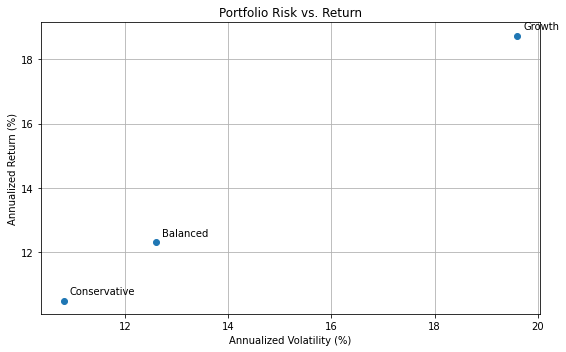

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    master_summary["Annualized Volatility"] * 100,
    master_summary["Annualized Return"] * 100
)

for portfolio in master_summary.index:
    x = master_summary.loc[portfolio, "Annualized Volatility"] * 100
    y = master_summary.loc[portfolio, "Annualized Return"] * 100

    plt.annotate(
        portfolio,
        (x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Portfolio Risk vs. Return")
plt.grid(True)

plt.tight_layout()
plt.show()

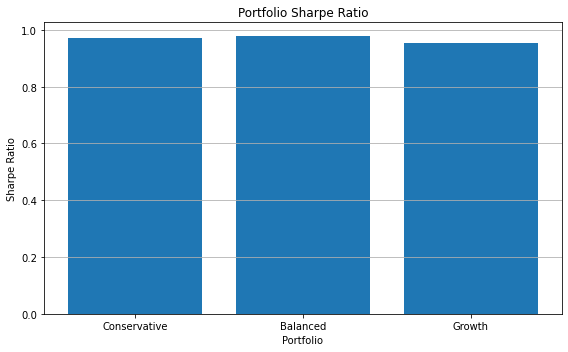

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    master_summary.index,
    master_summary["Sharpe Ratio"]
)

plt.xlabel("Portfolio")
plt.ylabel("Sharpe Ratio")
plt.title("Portfolio Sharpe Ratio")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

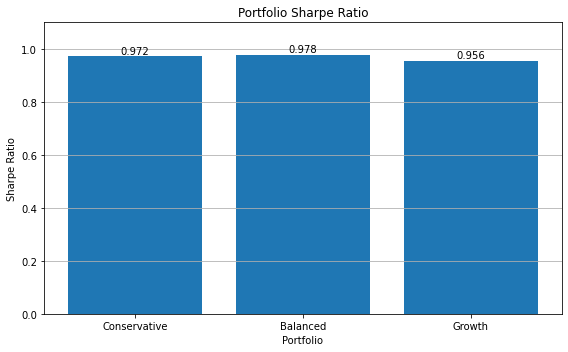

In [11]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    master_summary.index,
    master_summary["Sharpe Ratio"]
)

plt.xlabel("Portfolio")
plt.ylabel("Sharpe Ratio")
plt.title("Portfolio Sharpe Ratio")

# Add values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.ylim(0, 1.1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

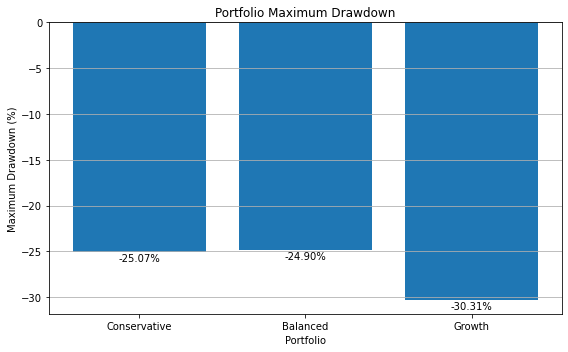

In [12]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    master_summary.index,
    master_summary["Maximum Drawdown"] * 100
)

plt.xlabel("Portfolio")
plt.ylabel("Maximum Drawdown (%)")
plt.title("Portfolio Maximum Drawdown")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height - 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.grid(axis="y")

plt.tight_layout()
plt.show()

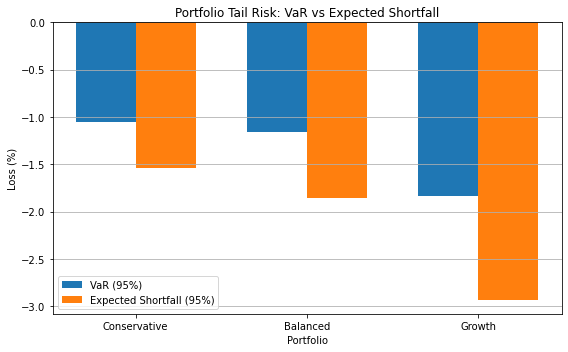

In [13]:
plt.figure(figsize=(8, 5))

x = np.arange(len(master_summary.index))
width = 0.35

plt.bar(
    x - width / 2,
    master_summary["Historical VaR (95%)"] * 100,
    width,
    label="VaR (95%)"
)

plt.bar(
    x + width / 2,
    master_summary["Expected Shortfall (95%)"] * 100,
    width,
    label="Expected Shortfall (95%)"
)

plt.xticks(x, master_summary.index)
plt.xlabel("Portfolio")
plt.ylabel("Loss (%)")
plt.title("Portfolio Tail Risk: VaR vs Expected Shortfall")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

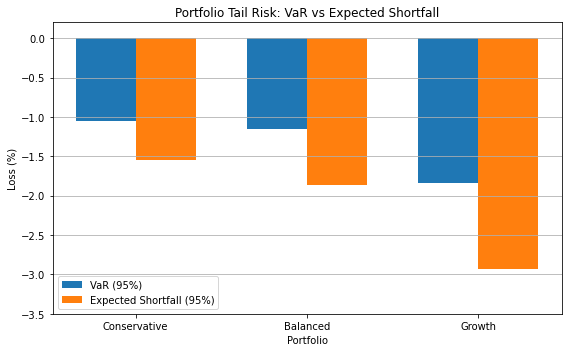

In [14]:
plt.figure(figsize=(8, 5))

x = np.arange(len(master_summary.index))
width = 0.35

plt.bar(
    x - width / 2,
    master_summary["Historical VaR (95%)"] * 100,
    width,
    label="VaR (95%)"
)

plt.bar(
    x + width / 2,
    master_summary["Expected Shortfall (95%)"] * 100,
    width,
    label="Expected Shortfall (95%)"
)

plt.xticks(x, master_summary.index)
plt.xlabel("Portfolio")
plt.ylabel("Loss (%)")
plt.title("Portfolio Tail Risk: VaR vs Expected Shortfall")
plt.legend()
plt.grid(axis="y")

plt.ylim(-3.5, 0.2)

plt.tight_layout()
plt.show()

In [15]:
portfolio_returns = pd.read_csv(
    project_path + r"\data\processed\portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

In [16]:
downside_returns = portfolio_returns.clip(upper=0)

downside_deviation = downside_returns.std() * np.sqrt(252)

sortino_ratio = (
    master_summary["Annualized Return"]
    / downside_deviation
)

sortino_ratio

Conservative    1.587498
Balanced        1.561576
Growth          1.522916
dtype: float64

In [17]:
master_summary["Sortino Ratio"] = sortino_ratio

master_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility,Sortino Ratio
Conservative,0.105047,0.108104,0.971717,0.369071,0.284624,0.039161,-0.010521,-0.015438,-0.250688,0.323070,1.587498
Balanced,0.123237,0.126049,0.977689,0.572608,0.215221,0.021016,-0.011563,-0.018586,-0.248956,0.449790,1.561576
Growth,0.187285,0.195982,0.955622,0.961729,0.194737,0.015599,-0.018348,-0.029343,-0.303071,0.707038,1.522916


In [18]:
master_summary.to_csv(
    project_path + r"\data\processed\master_summary.csv"
)

In [19]:
downside_returns = portfolio_returns.clip(upper=0)

In [20]:
master_summary.columns

Index(['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Beta',
       'Treynor Ratio', 'Jensen's Alpha', 'Historical VaR (95%)',
       'Expected Shortfall (95%)', 'Maximum Drawdown',
       'Maximum Rolling Volatility', 'Sortino Ratio'],
      dtype='object')

In [21]:
master_summary_display = master_summary.copy()

percentage_columns = [
    "Annualized Return",
    "Annualized Volatility",
    "Jensen's Alpha",
    "Historical VaR (95%)",
    "Expected Shortfall (95%)",
    "Maximum Drawdown",
    "Maximum Rolling Volatility"
]

for column in percentage_columns:
    master_summary_display[column] = (
        master_summary_display[column] * 100
    ).round(2)

ratio_columns = [
    "Sharpe Ratio",
    "Sortino Ratio",
    "Beta",
    "Treynor Ratio"
]

for column in ratio_columns:
    master_summary_display[column] = (
        master_summary_display[column].round(3)
    )

master_summary_display

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility,Sortino Ratio
Conservative,10.50,10.81,0.972,0.369,0.285,3.92,-1.05,-1.54,-25.07,32.31,1.587
Balanced,12.32,12.60,0.978,0.573,0.215,2.10,-1.16,-1.86,-24.90,44.98,1.562
Growth,18.73,19.60,0.956,0.962,0.195,1.56,-1.83,-2.93,-30.31,70.70,1.523


In [22]:
master_summary_display.to_csv(
    project_path + r"\data\processed\master_summary_display.csv"
)

In [23]:
stress_summary = pd.read_csv(
    project_path + r"\data\processed\stress_summary.csv",
    index_col=0
)

stress_summary

,2020 Stress Period Return,2022 Annual Return
Conservative,0.084777,-0.197331
Balanced,0.052294,-0.199534
Growth,0.075082,-0.265425


In [24]:
stress_summary

,2020 Stress Period Return,2022 Annual Return
Conservative,0.084777,-0.197331
Balanced,0.052294,-0.199534
Growth,0.075082,-0.265425


In [25]:
stress_summary_display = stress_summary * 100

stress_summary_display

,2020 Stress Period Return,2022 Annual Return
Conservative,8.477737,-19.733078
Balanced,5.229392,-19.953443
Growth,7.508217,-26.542484


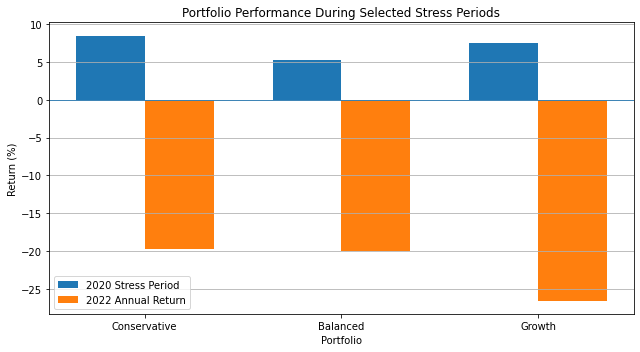

In [26]:
plt.figure(figsize=(9, 5))

x = np.arange(len(stress_summary_display.index))
width = 0.35

plt.bar(
    x - width / 2,
    stress_summary_display["2020 Stress Period Return"],
    width,
    label="2020 Stress Period"
)

plt.bar(
    x + width / 2,
    stress_summary_display["2022 Annual Return"],
    width,
    label="2022 Annual Return"
)

plt.xticks(x, stress_summary_display.index)
plt.xlabel("Portfolio")
plt.ylabel("Return (%)")
plt.title("Portfolio Performance During Selected Stress Periods")
plt.legend()
plt.axhline(0, linewidth=0.8)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [27]:
final_dashboard = master_summary_display.join(
    stress_summary_display
)

final_dashboard

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility,Sortino Ratio,2020 Stress Period Return,2022 Annual Return
Conservative,10.50,10.81,0.972,0.369,0.285,3.92,-1.05,-1.54,-25.07,32.31,1.587,8.477737,-19.733078
Balanced,12.32,12.60,0.978,0.573,0.215,2.10,-1.16,-1.86,-24.90,44.98,1.562,5.229392,-19.953443
Growth,18.73,19.60,0.956,0.962,0.195,1.56,-1.83,-2.93,-30.31,70.70,1.523,7.508217,-26.542484


In [28]:
stress_columns = [
    "2020 Stress Period Return",
    "2022 Annual Return"
]

for column in stress_columns:
    final_dashboard[column] = final_dashboard[column].round(2)

final_dashboard

,Annualized Return,Annualized Volatility,Sharpe Ratio,Beta,Treynor Ratio,Jensen's Alpha,Historical VaR (95%),Expected Shortfall (95%),Maximum Drawdown,Maximum Rolling Volatility,Sortino Ratio,2020 Stress Period Return,2022 Annual Return
Conservative,10.50,10.81,0.972,0.369,0.285,3.92,-1.05,-1.54,-25.07,32.31,1.587,8.48,-19.73
Balanced,12.32,12.60,0.978,0.573,0.215,2.10,-1.16,-1.86,-24.90,44.98,1.562,5.23,-19.95
Growth,18.73,19.60,0.956,0.962,0.195,1.56,-1.83,-2.93,-30.31,70.70,1.523,7.51,-26.54


In [29]:
final_dashboard.to_csv(
    project_path + r"\data\processed\final_dashboard.csv"
)

In [31]:
import os

reports_path = project_path + r"\reports"

os.makedirs(reports_path, exist_ok=True)

In [32]:
final_dashboard.to_excel(
    project_path + r"\reports\portfolio_analysis.xlsx",
    sheet_name="Dashboard"
)

In [33]:
os.listdir(reports_path)

['portfolio_analysis.xlsx']

In [34]:
import openpyxl

In [36]:
from openpyxl import Workbook

excel_path = project_path + r"\reports\portfolio_analysis.xlsx"

wb = Workbook()

# Remove the default sheet
default_sheet = wb.active
wb.remove(default_sheet)

# Create our main sheets
dashboard_ws = wb.create_sheet("Dashboard")
performance_ws = wb.create_sheet("Performance")
risk_ws = wb.create_sheet("Risk")
stress_ws = wb.create_sheet("Stress Periods")
methodology_ws = wb.create_sheet("Methodology")

wb.save(excel_path)

print("Excel workbook created successfully.")
print(excel_path)

Excel workbook created successfully.
C:\Users\Bawan Singh\OneDrive\Documents\Arshleen\market-portfolio-risk-analysis\reports\portfolio_analysis.xlsx


In [37]:
from openpyxl.utils.dataframe import dataframe_to_rows

# Write the final dashboard to the Dashboard sheet
for row in dataframe_to_rows(final_dashboard, index=True, header=True):
    dashboard_ws.append(row)

print("Dashboard data added successfully.")

Dashboard data added successfully.


In [38]:
# Write performance data to the Performance sheet
for row in dataframe_to_rows(
    master_summary_display,
    index=True,
    header=True
):
    performance_ws.append(row)

print("Performance data added successfully.")

Performance data added successfully.


In [39]:
# Write risk data to the Risk sheet
for row in dataframe_to_rows(
    risk_summary,
    index=True,
    header=True
):
    risk_ws.append(row)

print("Risk data added successfully.")

Risk data added successfully.


In [40]:
# Write stress-period data to the Stress Periods sheet
for row in dataframe_to_rows(
    stress_summary_display,
    index=True,
    header=True
):
    stress_ws.append(row)

print("Stress-period data added successfully.")

Stress-period data added successfully.


In [41]:
methodology_data = [
    ["Metric", "Methodology"],
    ["Annualized Return", "Mean daily return × 252"],
    ["Annualized Volatility", "Daily standard deviation × √252"],
    ["Sharpe Ratio", "Annualized Return ÷ Annualized Volatility; assumes 0% risk-free rate"],
    ["Sortino Ratio", "Annualized Return ÷ Annualized Downside Deviation; simplified downside calculation"],
    ["Beta", "Covariance of portfolio returns with SPY ÷ Variance of SPY"],
    ["Treynor Ratio", "Annualized Return ÷ Beta; assumes 0% risk-free rate"],
    ["Jensen's Alpha", "Portfolio Return − (Beta × SPY Return); assumes 0% risk-free rate"],
    ["Historical VaR (95%)", "5th percentile of daily portfolio returns"],
    ["Expected Shortfall (95%)", "Average return of observations at or below the 95% VaR threshold"],
    ["Maximum Drawdown", "Largest decline from a previous cumulative-return peak"],
    ["Rolling Volatility", "30-trading-day rolling standard deviation × √252"],
    ["2020 Stress Period", "Portfolio return from February 1, 2020 through June 30, 2020"],
    ["2022 Stress Period", "Portfolio return over calendar year 2022"],
]

for row in methodology_data:
    methodology_ws.append(row)

print("Methodology added successfully.")

Methodology added successfully.


In [42]:
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

# ---------- Dashboard title ----------
dashboard_ws.insert_rows(1, 3)

dashboard_ws["A1"] = "Market Portfolio Risk & Performance Analysis"
dashboard_ws["A1"].font = Font(size=18, bold=True)
dashboard_ws["A2"] = "Quantitative comparison of Conservative, Balanced and Growth portfolios"
dashboard_ws["A2"].font = Font(italic=True)

# ---------- Header formatting ----------
header_fill = PatternFill(
    fill_type="solid",
    fgColor="1F4E78"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)

thin_border = Border(
    bottom=Side(style="thin", color="B7B7B7")
)

# Find the header row
header_row = 4

for cell in dashboard_ws[header_row]:
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(
        horizontal="center",
        vertical="center"
    )

# ---------- Format data ----------
percentage_columns = [
    "Annualized Return",
    "Annualized Volatility",
    "Jensen's Alpha",
    "Historical VaR (95%)",
    "Expected Shortfall (95%)",
    "Maximum Drawdown",
    "Maximum Rolling Volatility",
    "2020 Stress Period Return",
    "2022 Annual Return"
]

ratio_columns = [
    "Sharpe Ratio",
    "Sortino Ratio",
    "Beta",
    "Treynor Ratio"
]

# Identify columns by header
headers = {
    cell.value: cell.column
    for cell in dashboard_ws[header_row]
}

for column_name in percentage_columns:
    if column_name in headers:
        col = headers[column_name]

        for row in range(header_row + 1, dashboard_ws.max_row + 1):
            dashboard_ws.cell(row, col).number_format = "0.00%"

for column_name in ratio_columns:
    if column_name in headers:
        col = headers[column_name]

        for row in range(header_row + 1, dashboard_ws.max_row + 1):
            dashboard_ws.cell(row, col).number_format = "0.000"

# ---------- Borders and alignment ----------
for row in dashboard_ws.iter_rows(
    min_row=header_row,
    max_row=dashboard_ws.max_row
):
    for cell in row:
        cell.border = thin_border
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

# ---------- Column widths ----------
for column in dashboard_ws.columns:
    max_length = 0
    column_letter = get_column_letter(column[0].column)

    for cell in column:
        if cell.value is not None:
            max_length = max(
                max_length,
                len(str(cell.value))
            )

    dashboard_ws.column_dimensions[column_letter].width = min(
        max_length + 3,
        24
    )

# ---------- Freeze header ----------
dashboard_ws.freeze_panes = "B5"

print("Dashboard formatting applied successfully.")

Dashboard formatting applied successfully.


In [43]:
# Sheets to format
sheets_to_format = [
    performance_ws,
    risk_ws,
    stress_ws,
    methodology_ws
]

for ws in sheets_to_format:

    # Header row
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    # Borders and alignment
    for row in ws.iter_rows():
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center"
            )

    # Column widths
    for column in ws.columns:
        max_length = 0
        column_letter = get_column_letter(column[0].column)

        for cell in column:
            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        ws.column_dimensions[column_letter].width = min(
            max_length + 3,
            35
        )

    # Freeze the header
    ws.freeze_panes = "B2"


# ---------- Performance number formatting ----------
performance_headers = {
    cell.value: cell.column
    for cell in performance_ws[1]
}

for column_name in percentage_columns:
    if column_name in performance_headers:
        col = performance_headers[column_name]

        for row in range(2, performance_ws.max_row + 1):
            performance_ws.cell(row, col).number_format = "0.00%"

for column_name in ratio_columns:
    if column_name in performance_headers:
        col = performance_headers[column_name]

        for row in range(2, performance_ws.max_row + 1):
            performance_ws.cell(row, col).number_format = "0.000"


# ---------- Risk number formatting ----------
for row in range(2, risk_ws.max_row + 1):
    for col in range(2, risk_ws.max_column + 1):
        risk_ws.cell(row, col).number_format = "0.00%"


# ---------- Stress number formatting ----------
for row in range(2, stress_ws.max_row + 1):
    for col in range(2, stress_ws.max_column + 1):
        stress_ws.cell(row, col).number_format = "0.00%"


# ---------- Methodology ----------
methodology_ws.column_dimensions["A"].width = 30
methodology_ws.column_dimensions["B"].width = 80

for row in range(2, methodology_ws.max_row + 1):
    methodology_ws.cell(row, 2).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True
    )

print("All supporting sheets formatted successfully.")

All supporting sheets formatted successfully.


In [44]:
from openpyxl.chart import BarChart, Reference

# ============================================================
# CHART 1 — Annualized Return vs Annualized Volatility
# ============================================================

chart1 = BarChart()

chart1.type = "col"
chart1.style = 10
chart1.title = "Portfolio Return vs Volatility"
chart1.y_axis.title = "Percentage"
chart1.x_axis.title = "Portfolio"

# Find the relevant columns
return_col = headers["Annualized Return"]
volatility_col = headers["Annualized Volatility"]

data = Reference(
    dashboard_ws,
    min_col=return_col,
    max_col=volatility_col,
    min_row=header_row,
    max_row=header_row + 3
)

categories = Reference(
    dashboard_ws,
    min_col=1,
    min_row=header_row + 1,
    max_row=header_row + 3
)

chart1.add_data(data, titles_from_data=True)
chart1.set_categories(categories)

chart1.height = 8
chart1.width = 14

dashboard_ws.add_chart(chart1, "A10")


# ============================================================
# CHART 2 — VaR vs Expected Shortfall
# ============================================================

chart2 = BarChart()

chart2.type = "col"
chart2.style = 11
chart2.title = "VaR vs Expected Shortfall"
chart2.y_axis.title = "Loss"
chart2.x_axis.title = "Portfolio"

var_col = headers["Historical VaR (95%)"]
es_col = headers["Expected Shortfall (95%)"]

data2 = Reference(
    dashboard_ws,
    min_col=var_col,
    max_col=es_col,
    min_row=header_row,
    max_row=header_row + 3
)

chart2.add_data(
    data2,
    titles_from_data=True
)

chart2.set_categories(categories)

chart2.height = 8
chart2.width = 14

dashboard_ws.add_chart(chart2, "P10")


print("Dashboard charts added successfully.")

Dashboard charts added successfully.


In [45]:
# Save the completed Excel report
wb.save(excel_path)

print("Professional Excel report saved successfully.")
print(excel_path)

Professional Excel report saved successfully.
C:\Users\Bawan Singh\OneDrive\Documents\Arshleen\market-portfolio-risk-analysis\reports\portfolio_analysis.xlsx
